In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 1. Load the California Housing Dataset

In [24]:
housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name="MedHouseVal")

print("Features:")
display(X.head())

print("Target:")
display(y.head())

print("Dataset shape:", X.shape)

Features:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Target:


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

Dataset shape: (20640, 8)


## 2. Data Preprocessing

In [25]:
# Check missing values
print("Missing values in features:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in features:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Missing values in target:
0


In [26]:
# Statistical summary
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [27]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (16512, 8)
Testing set: (4128, 8)


In [28]:
# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## 3. Exploratory Data Analysis (EDA)

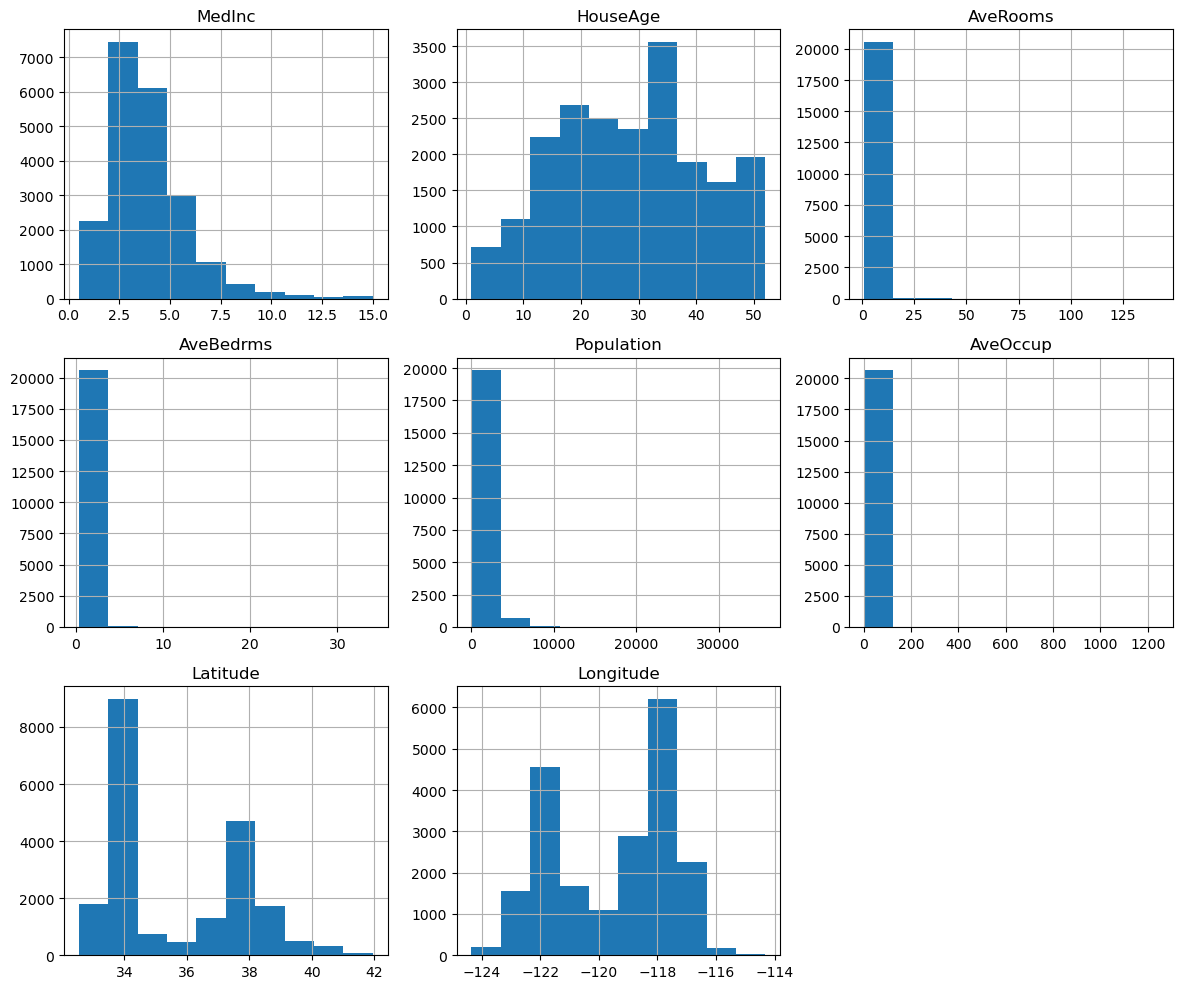

In [29]:
X.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

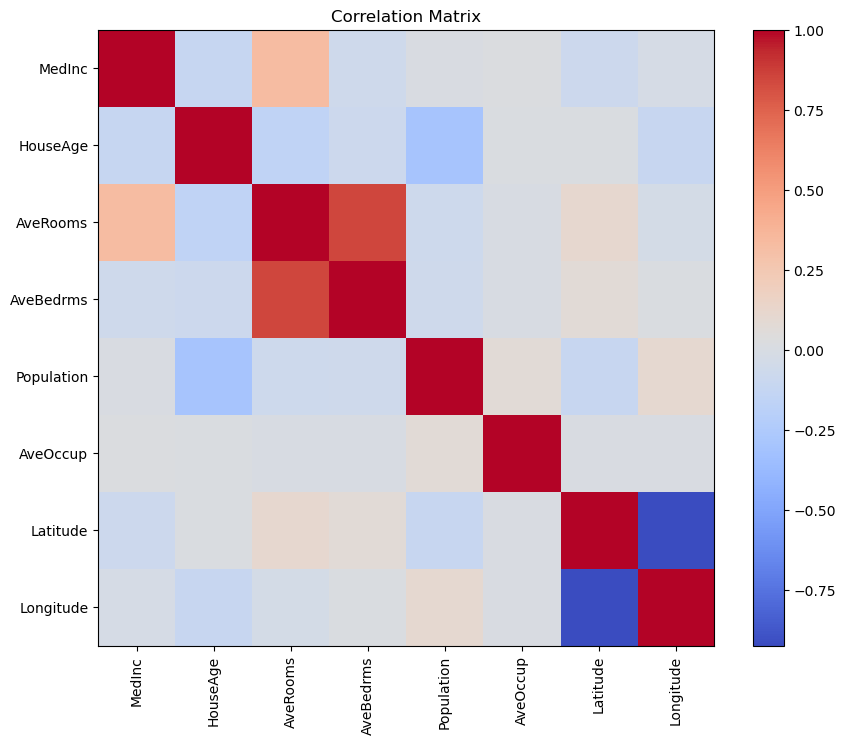

In [30]:
# Correlation matrix
correlation = X.corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(X.columns)), X.columns, rotation=90)
plt.yticks(range(len(X.columns)), X.columns)
plt.title("Correlation Matrix")
plt.show()

**How it works:** Linear Regression models the target as a linear combination of the input features.

**Why suitable:** It provides a simple baseline for predicting California median house values and is easy to interpret.

## 4. Linear Regression

In [31]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MSE:", mse_lr)
print("MAE:", mae_lr)
print("R2 Score:", r2_lr)

Linear Regression
MSE: 0.5558915986952441
MAE: 0.5332001304956565
R2 Score: 0.575787706032451


**How it works:** A Decision Tree repeatedly splits the data into smaller groups using feature-based rules and predicts a value at each leaf.

**Why suitable:** It can capture non-linear relationships between housing features and house prices without requiring a linear relationship.

## 5. Decision Tree Regressor

In [32]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor")
print("MSE:", mse_dt)
print("MAE:", mae_dt)
print("R2 Score:", r2_dt)

Decision Tree Regressor
MSE: 0.495235205629094
MAE: 0.45467918846899225
R2 Score: 0.622075845135081


**How it works:** Random Forest combines predictions from many decision trees trained using randomized samples/features.

**Why suitable:** Housing prices can depend on complex non-linear interactions, which an ensemble of trees can model effectively.

## 6. Random Forest Regressor

In [33]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor")
print("MSE:", mse_rf)
print("MAE:", mae_rf)
print("R2 Score:", r2_rf)

Random Forest Regressor
MSE: 0.2553684927247781
MAE: 0.3275425684593025
R2 Score: 0.8051230593157366


**How it works:** Gradient Boosting builds trees sequentially, with each new tree trying to reduce the errors made by the previous trees.

**Why suitable:** It can model complex non-linear patterns and often provides strong regression performance.

## 7. Gradient Boosting Regressor

In [34]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

mse_gb = mean_squared_error(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regressor")
print("MSE:", mse_gb)
print("MAE:", mae_gb)
print("R2 Score:", r2_gb)

Gradient Boosting Regressor
MSE: 0.2939973248643864
MAE: 0.3716425690425596
R2 Score: 0.7756446042829697


**How it works:** SVR finds a function that predicts the target while keeping prediction errors within a specified margin; the RBF kernel can model non-linear relationships.

**Why suitable:** SVR can model non-linear relationships in housing data, and feature scaling helps it work effectively.

## 8. Support Vector Regressor (SVR)

In [35]:
svr = SVR(kernel="rbf")
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("Support Vector Regressor")
print("MSE:", mse_svr)
print("MAE:", mae_svr)
print("R2 Score:", r2_svr)

Support Vector Regressor
MSE: 0.3570040319338651
MAE: 0.3985990769520539
R2 Score: 0.7275628923016773


## 9. Model Evaluation and Comparison

In [36]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR"
    ],
    "MSE": [mse_lr, mse_dt, mse_rf, mse_gb, mse_svr],
    "MAE": [mae_lr, mae_dt, mae_rf, mae_gb, mae_svr],
    "R2 Score": [r2_lr, r2_dt, r2_rf, r2_gb, r2_svr]
})

results

,Model,MSE,MAE,R2 Score
0,Linear Regression,0.555892,0.533200,0.575788
1,Decision Tree,0.495235,0.454679,0.622076
2,Random Forest,0.255368,0.327543,0.805123
3,Gradient Boosting,0.293997,0.371643,0.775645
4,SVR,0.357004,0.398599,0.727563


In [37]:
# Sort by R2 score
results.sort_values(by="R2 Score", ascending=False)

,Model,MSE,MAE,R2 Score
2,Random Forest,0.255368,0.327543,0.805123
3,Gradient Boosting,0.293997,0.371643,0.775645
4,SVR,0.357004,0.398599,0.727563
1,Decision Tree,0.495235,0.454679,0.622076
0,Linear Regression,0.555892,0.533200,0.575788


## 10. 5-Fold Cross-Validation

In [38]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf"))
    ])
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model, X, y, cv=5, scoring="r2", n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean R2": scores.mean(),
        "Std R2": scores.std()
    })

cv_results = pd.DataFrame(cv_results)
cv_results

,Model,Mean R2,Std R2
0,Linear Regression,0.553031,0.061692
1,Decision Tree,0.355643,0.084729
2,Random Forest,0.656119,0.077762
3,Gradient Boosting,0.669835,0.040467
4,SVR,0.668696,0.056407


## 11. Hyperparameter Tuning for All Models

GridSearchCV is used with 5-fold cross-validation. The selected parameters are intentionally kept small so the notebook remains practical to run. The main hyperparameters are:

- Linear Regression: `fit_intercept`
- Decision Tree: `max_depth`, `min_samples_split`
- Random Forest: `n_estimators`, `max_depth`, `min_samples_split`
- Gradient Boosting: `n_estimators`, `learning_rate`, `max_depth`
- SVR: `C`, `epsilon`, `kernel`

These parameters control model complexity, regularization, number of trees, learning rate, or SVR margin/penalty.

In [39]:
tuning_pipelines = {
    "Linear Regression": (
        Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
        {"model__fit_intercept": [True, False]}
    ),
    "Decision Tree": (
        DecisionTreeRegressor(random_state=42),
        {"max_depth": [None, 10, 20], "min_samples_split": [2, 5]}
    ),
    "Random Forest": (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {"n_estimators": [100, 200], "max_depth": [None, 20], "min_samples_split": [2, 5]}
    ),
    "Gradient Boosting": (
        GradientBoostingRegressor(random_state=42),
        {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [2, 3]}
    ),
    "SVR": (
        Pipeline([("scaler", StandardScaler()), ("model", SVR())]),
        {"model__C": [1, 10], "model__epsilon": [0.1, 0.2], "model__kernel": ["rbf"]}
    )
}

tuned_models = {}
tuning_results = []

for name, (model, params) in tuning_pipelines.items():
    grid = GridSearchCV(model, params, cv=5, scoring="r2", n_jobs=-1)
    grid.fit(X_train, y_train)
    tuned_models[name] = grid.best_estimator_
    tuning_results.append({
        "Model": name,
        "Best CV R2": grid.best_score_,
        "Best Parameters": grid.best_params_
    })

tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df

,Model,Best CV R2,Best Parameters
0,Linear Regression,0.611484,{'model__fit_intercept': True}
1,Decision Tree,0.694734,"{'max_depth': 10, 'min_samples_split': 5}"
2,Random Forest,0.805052,"{'max_depth': 20, 'min_samples_split': 2, 'n_e..."
3,Gradient Boosting,0.807425,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
4,SVR,0.761573,"{'model__C': 10, 'model__epsilon': 0.2, 'model..."


### Evaluate the tuned models on the test set

In [40]:
tuned_test_results = []

for name, model in tuned_models.items():
    pred = model.predict(X_test)
    tuned_test_results.append({
        "Model": name,
        "MSE": mean_squared_error(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "R2 Score": r2_score(y_test, pred)
    })

tuned_test_results = pd.DataFrame(tuned_test_results)
tuned_test_results

,Model,MSE,MAE,R2 Score
0,Linear Regression,0.555892,0.533200,0.575788
1,Decision Tree,0.410882,0.432173,0.686448
2,Random Forest,0.254592,0.327114,0.805715
3,Gradient Boosting,0.261498,0.348343,0.800445
4,SVR,0.321273,0.379624,0.754830


## 12. Evaluate the Tuned Random Forest

In [45]:
best_rf = tuned_models["Random Forest"]

y_pred_best = best_rf.predict(X_test)

tuned_mse = mean_squared_error(y_test, y_pred_best)
tuned_mae = mean_absolute_error(y_test, y_pred_best)
tuned_r2 = r2_score(y_test, y_pred_best)

print("Tuned Random Forest")
print("MSE:", tuned_mse)
print("MAE:", tuned_mae)
print("R2 Score:", tuned_r2)

Tuned Random Forest
MSE: 0.2545922861286096
MAE: 0.3271140672274751
R2 Score: 0.8057153985083529


## 13. Final Model Comparison

In [46]:
# Combine original test results with tuned model results
final_results = pd.concat([results, tuned_test_results], ignore_index=True)
final_results.sort_values(by="R2 Score", ascending=False)

,Model,MSE,MAE,R2 Score
7,Random Forest,0.254592,0.327114,0.805715
2,Random Forest,0.255368,0.327543,0.805123
8,Gradient Boosting,0.261498,0.348343,0.800445
3,Gradient Boosting,0.293997,0.371643,0.775645
9,SVR,0.321273,0.379624,0.754830
4,SVR,0.357004,0.398599,0.727563
6,Decision Tree,0.410882,0.432173,0.686448
1,Decision Tree,0.495235,0.454679,0.622076
0,Linear Regression,0.555892,0.533200,0.575788
5,Linear Regression,0.555892,0.533200,0.575788


## 14. Final Selection and Conclusion

The final model is selected using the test-set MSE, MAE and R² values together with the 5-fold cross-validation results and hyperparameter tuning results.

- **Lower MSE** means smaller squared prediction errors.
- **Lower MAE** means smaller average absolute prediction error.
- **Higher R²** means the model explains more of the variation in the target.

The code below identifies the model with the highest R² and also reports the model with the lowest R². This provides a data-based justification for the best and worst performers rather than assuming them in advance.

In [47]:
best_model = final_results.loc[final_results["R2 Score"].idxmax()]
worst_model = final_results.loc[final_results["R2 Score"].idxmin()]

print("Best-performing model:", best_model["Model"])
print("Best R2 Score:", best_model["R2 Score"])
print("Best MSE:", best_model["MSE"])
print("Best MAE:", best_model["MAE"])

print("\nWorst-performing model:", worst_model["Model"])
print("Worst R2 Score:", worst_model["R2 Score"])
print("Worst MSE:", worst_model["MSE"])
print("Worst MAE:", worst_model["MAE"])

Best-performing model: Random Forest
Best R2 Score: 0.8057153985083529
Best MSE: 0.2545922861286096
Best MAE: 0.3271140672274751

Worst-performing model: Linear Regression
Worst R2 Score: 0.575787706032451
Worst MSE: 0.5558915986952441
Worst MAE: 0.5332001304956565
